In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn-clean.csv')
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0,1,0.115423,0.001275,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.472222,1,0,0.385075,0.215867,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,0.027778,1,1,0.354229,0.010310,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.625000,0,0,0.239303,0.210241,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0.027778,1,1,0.521891,0.015330,1,...,0,0,0,0,0,0,0,0,1,0


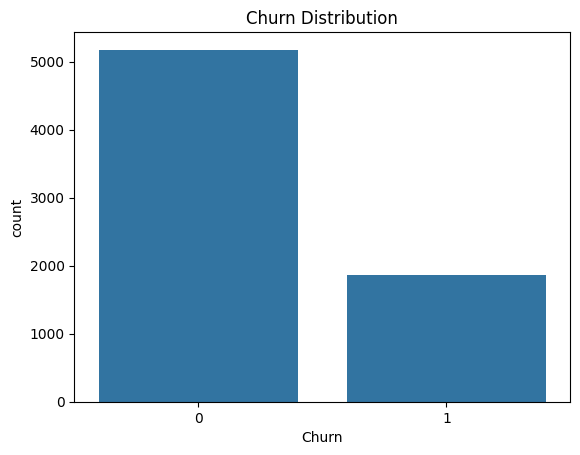

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [32]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

df['Churn'].value_counts(normalize=True)

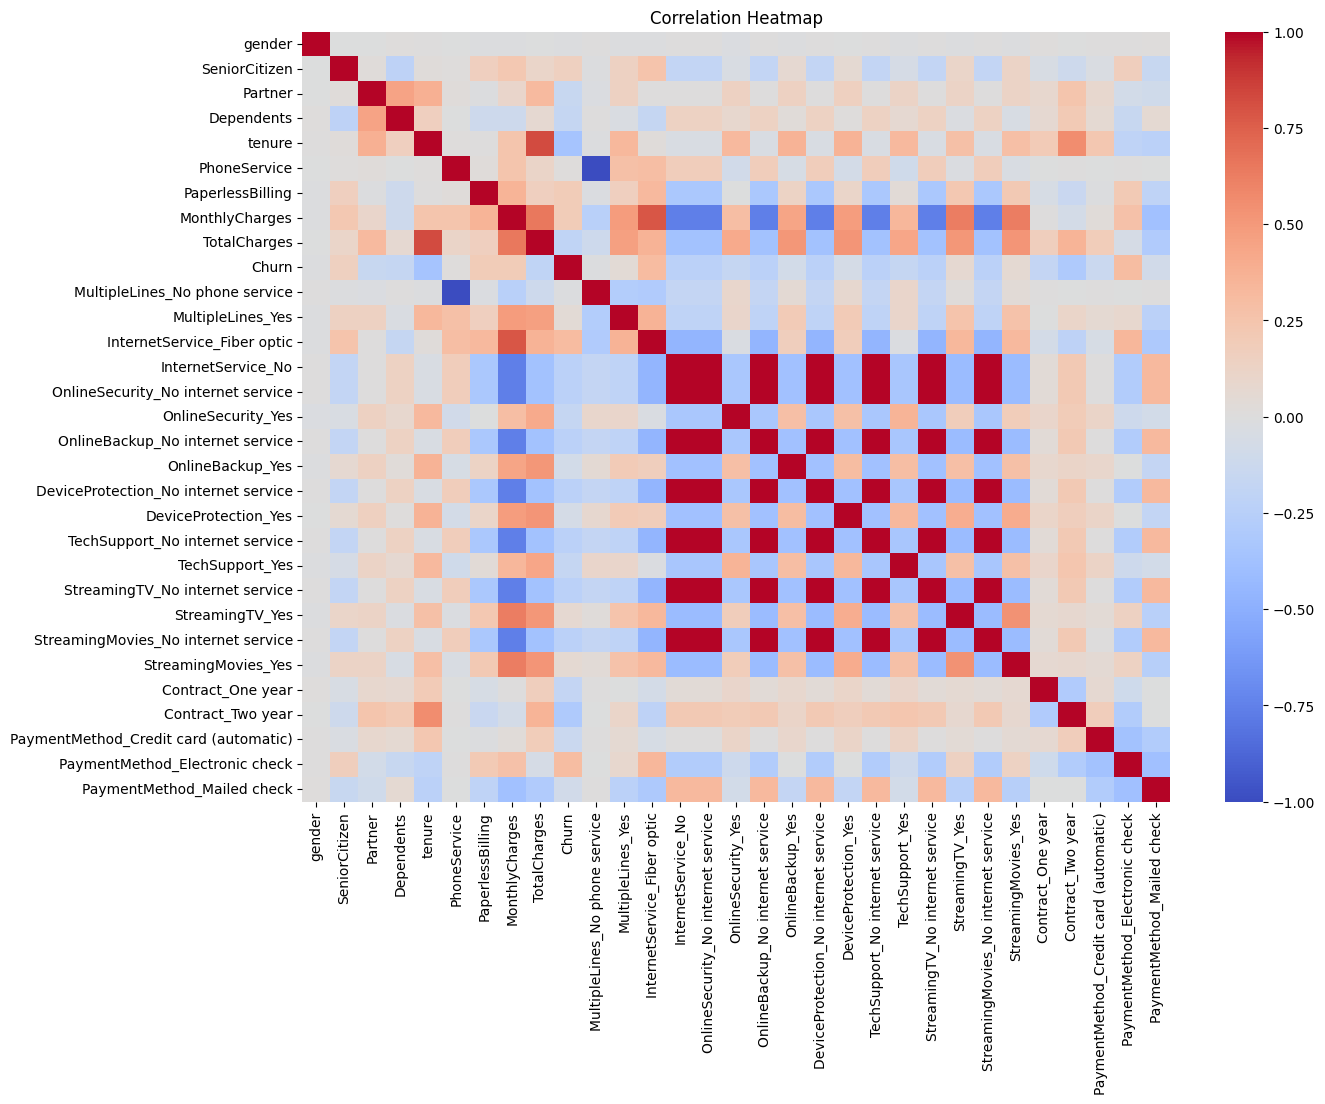

In [33]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [34]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [35]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(model):
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]
    return {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, proba)
    }

print("Logistic Regression:", evaluate(log_reg))
print("Random Forest:", evaluate(rf))
print("XGBoost:", evaluate(xgb))


Logistic Regression: {'Accuracy': 0.7984386089425124, 'Precision': 0.640625, 'Recall': 0.5481283422459893, 'F1': 0.590778097982709, 'ROC-AUC': 0.8406623782582863}
Random Forest: {'Accuracy': 0.7863733144073811, 'Precision': 0.6254295532646048, 'Recall': 0.48663101604278075, 'F1': 0.5473684210526316, 'ROC-AUC': 0.8238187501614611}
XGBoost: {'Accuracy': 0.7899219304471257, 'Precision': 0.6234177215189873, 'Recall': 0.5267379679144385, 'F1': 0.5710144927536231, 'ROC-AUC': 0.827638275336485}


In [39]:
import joblib

#save the Logistic Regression model
joblib.dump(log_reg, '../models/experiments/notebook_logreg_model.pkl')
print("Notebook Logistic Regression model saved as 'notebook_logreg_model.pkl'")

#save the Random Forest model
joblib.dump(rf, '../models/experiments/notebook_rf_model.pkl')
print("Notebook Random Forest model saved as 'notebook_rf_model.pkl'")

#save the XGBoost model
joblib.dump(log_reg, '../models/experiments/notebook_XGB_model.pkl')
print("Notebook XGBoost model saved as 'notebook_XGB_model.pkl'")

Notebook Logistic Regression model saved as 'notebook_logreg_model.pkl'
Notebook Random Forest model saved as 'notebook_rf_model.pkl'
Notebook XGBoost model saved as 'notebook_XGB_model.pkl'
